# 06 Final Model Comparison and Ablation Study

## CSE 445: Machine Learning Project

**Project Title:** Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis  
**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Notebook Objective

This notebook summarizes and compares all completed experiments.

The goal is to perform an ablation-style analysis across four models:

1. RGB-only spatial baseline
2. FFT-only frequency baseline
3. Hybrid RGB-FFT fusion model
4. Hybrid RGB-FFT-Radial Energy fusion model

This comparison helps determine whether frequency-domain and radial energy features improve AI-generated image detection when combined with RGB spatial features.

# 1. Research Context

Recent frequency-aware AI-generated image detection studies suggest that synthetic images may contain artifacts in both spatial and frequency domains.

In this project, four models were trained and evaluated on the same balanced dataset split:

| Split | Real | Fake | Total |
|---|---:|---:|---:|
| Training | 1200 | 1200 | 2400 |
| Validation | 400 | 400 | 800 |
| Testing | 400 | 400 | 800 |

Using the same dataset split allows fair comparison across models.

# 1. Research Context

Recent frequency-aware AI-generated image detection studies suggest that synthetic images may contain artifacts in both spatial and frequency domains.

In this project, four models were trained and evaluated on the same balanced dataset split:

| Split | Real | Fake | Total |
|---|---:|---:|---:|
| Training | 1200 | 1200 | 2400 |
| Validation | 400 | 400 | 800 |
| Testing | 400 | 400 | 800 |

Using the same dataset split allows fair comparison across models.

In [5]:
# ============================================================
# 3. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# 4. Final Results Table
# ============================================================

results_data = {
    "Model": [
        "ResNet18 RGB Baseline",
        "ResNet18 FFT Baseline",
        "Hybrid RGB-FFT Fusion",
        "Hybrid RGB-FFT-Radial Fusion"
    ],
    "Input Type": [
        "RGB",
        "FFT Magnitude",
        "RGB + FFT",
        "RGB + FFT + Radial Energy"
    ],
    "Best Validation Accuracy": [
        0.8875,
        0.6700,
        0.8850,
        0.8725
    ],
    "Test Accuracy": [
        0.8700,
        0.6500,
        0.8425,
        0.86875
    ],
    "Precision": [
        0.8426,
        0.6322,
        0.8325,
        0.9155
    ],
    "Recall": [
        0.9100,
        0.7175,
        0.8575,
        0.8125
    ],
    "F1-score": [
        0.8750,
        0.6721,
        0.8448,
        0.8609
    ],
    "Training Time (min)": [
        13.93,
        12.80,
        25.60,
        39.37
    ]
}

results_df = pd.DataFrame(results_data)

results_df

,Model,Input Type,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1-score,Training Time (min)
0,ResNet18 RGB Baseline,RGB,0.8875,0.87000,0.8426,0.9100,0.8750,13.93
1,ResNet18 FFT Baseline,FFT Magnitude,0.6700,0.65000,0.6322,0.7175,0.6721,12.80
2,Hybrid RGB-FFT Fusion,RGB + FFT,0.8850,0.84250,0.8325,0.8575,0.8448,25.60
3,Hybrid RGB-FFT-Radial Fusion,RGB + FFT + Radial Energy,0.8725,0.86875,0.9155,0.8125,0.8609,39.37


# ============================================================
# 5. Results Table in Percentage Format
# ============================================================

percentage_df = results_df.copy()

metric_columns = [
    "Best Validation Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for col in metric_columns:
    percentage_df[col] = (percentage_df[col] * 100).round(2)

percentage_df

In [17]:
# ============================================================
# 5. Results Table in Percentage Format
# ============================================================

percentage_df = results_df.copy()

metric_columns = [
    "Best Validation Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for col in metric_columns:
    percentage_df[col] = (percentage_df[col] * 100).round(2)

percentage_df

,Model,Input Type,Best Validation Accuracy,Test Accuracy,Precision,Recall,F1-score,Training Time (min)
0,ResNet18 RGB Baseline,RGB,88.75,87.00,84.26,91.00,87.50,13.93
1,ResNet18 FFT Baseline,FFT Magnitude,67.00,65.00,63.22,71.75,67.21,12.80
2,Hybrid RGB-FFT Fusion,RGB + FFT,88.50,84.25,83.25,85.75,84.48,25.60
3,Hybrid RGB-FFT-Radial Fusion,RGB + FFT + Radial Energy,87.25,86.88,91.55,81.25,86.09,39.37


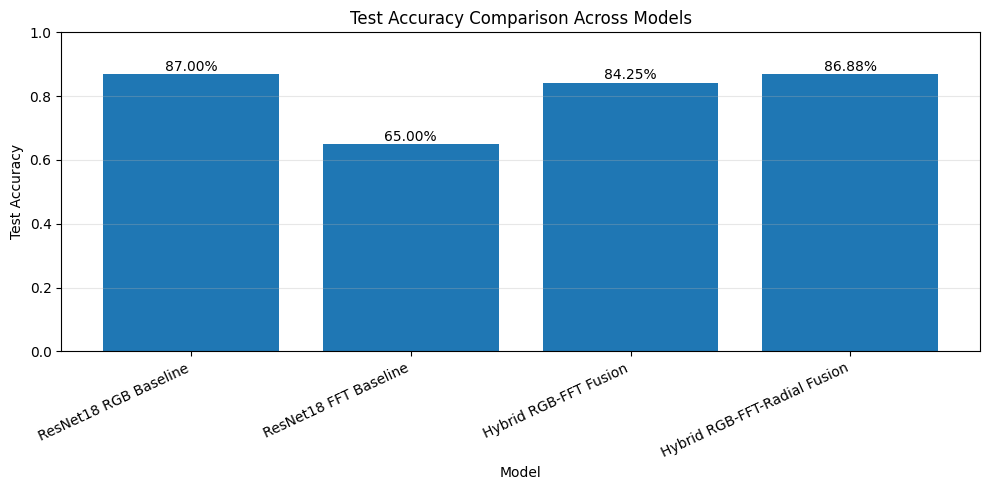

In [7]:
# ============================================================
# 6. Test Accuracy Comparison
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(results_df["Test Accuracy"]):
    plt.text(i, value + 0.01, f"{value*100:.2f}%", ha="center")

plt.tight_layout()
plt.show()

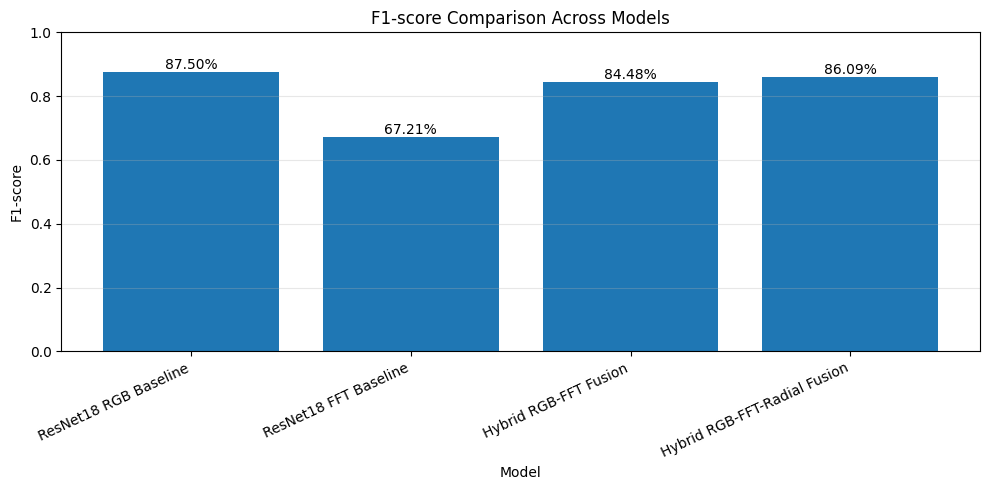

In [8]:
# ============================================================
# 7. F1-score Comparison
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["F1-score"])
plt.title("F1-score Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1.0)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(results_df["F1-score"]):
    plt.text(i, value + 0.01, f"{value*100:.2f}%", ha="center")

plt.tight_layout()
plt.show()

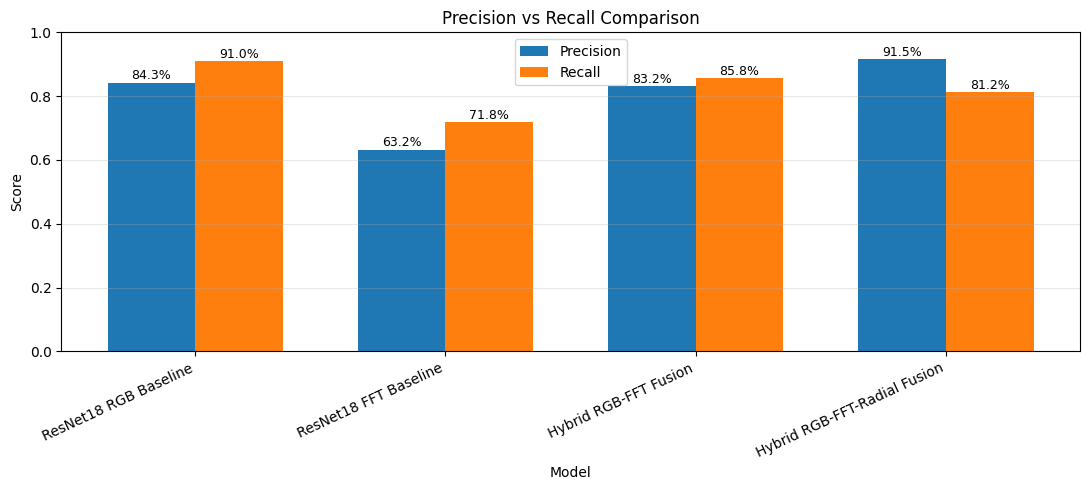

In [9]:
# ============================================================
# 8. Precision and Recall Comparison
# ============================================================

x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, results_df["Precision"], width, label="Precision")
plt.bar(x + width/2, results_df["Recall"], width, label="Recall")

plt.title("Precision vs Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(x, results_df["Model"], rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()

for i, value in enumerate(results_df["Precision"]):
    plt.text(i - width/2, value + 0.01, f"{value*100:.1f}%", ha="center", fontsize=9)

for i, value in enumerate(results_df["Recall"]):
    plt.text(i + width/2, value + 0.01, f"{value*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

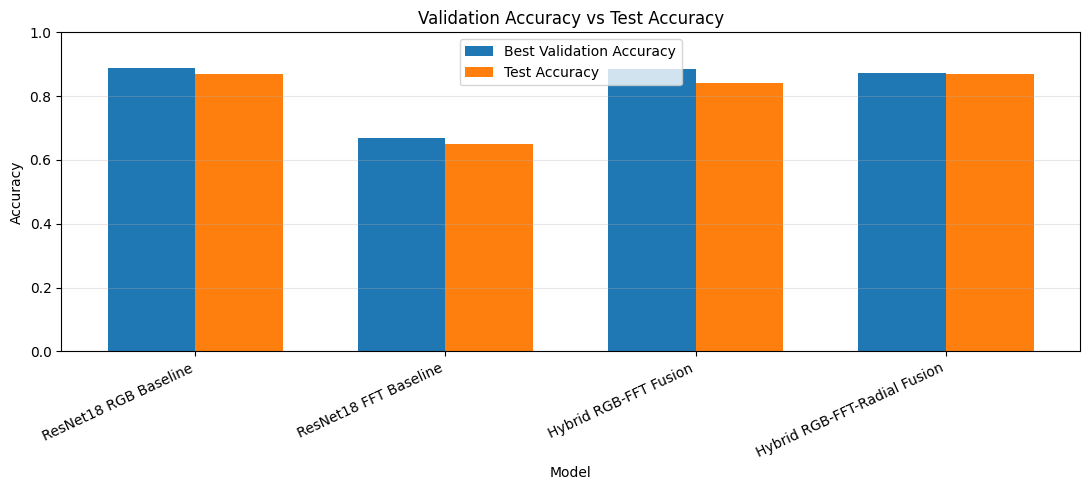

In [10]:
# ============================================================
# 9. Validation vs Test Accuracy Comparison
# ============================================================

x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, results_df["Best Validation Accuracy"], width, label="Best Validation Accuracy")
plt.bar(x + width/2, results_df["Test Accuracy"], width, label="Test Accuracy")

plt.title("Validation Accuracy vs Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(x, results_df["Model"], rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 4. Confusion Matrix Summary

The confusion matrices from the completed experiments are summarized below.

The test set contains:

- 400 real images
- 400 fake images

Confusion matrix format:

| | Predicted Real | Predicted Fake |
|---|---:|---:|
| Actual Real | True Real | False Fake |
| Actual Fake | False Real | True Fake |

In [11]:
# ============================================================
# 10. Confusion Matrix Summary
# ============================================================

confusion_data = {
    "Model": [
        "ResNet18 RGB Baseline",
        "ResNet18 FFT Baseline",
        "Hybrid RGB-FFT Fusion",
        "Hybrid RGB-FFT-Radial Fusion"
    ],
    "Actual Real → Predicted Real": [
        332,
        233,
        331,
        370
    ],
    "Actual Real → Predicted Fake": [
        68,
        167,
        69,
        30
    ],
    "Actual Fake → Predicted Real": [
        36,
        113,
        57,
        75
    ],
    "Actual Fake → Predicted Fake": [
        364,
        287,
        343,
        325
    ]
}

confusion_df = pd.DataFrame(confusion_data)
confusion_df

,Model,Actual Real → Predicted Real,Actual Real → Predicted Fake,Actual Fake → Predicted Real,Actual Fake → Predicted Fake
0,ResNet18 RGB Baseline,332,68,36,364
1,ResNet18 FFT Baseline,233,167,113,287
2,Hybrid RGB-FFT Fusion,331,69,57,343
3,Hybrid RGB-FFT-Radial Fusion,370,30,75,325


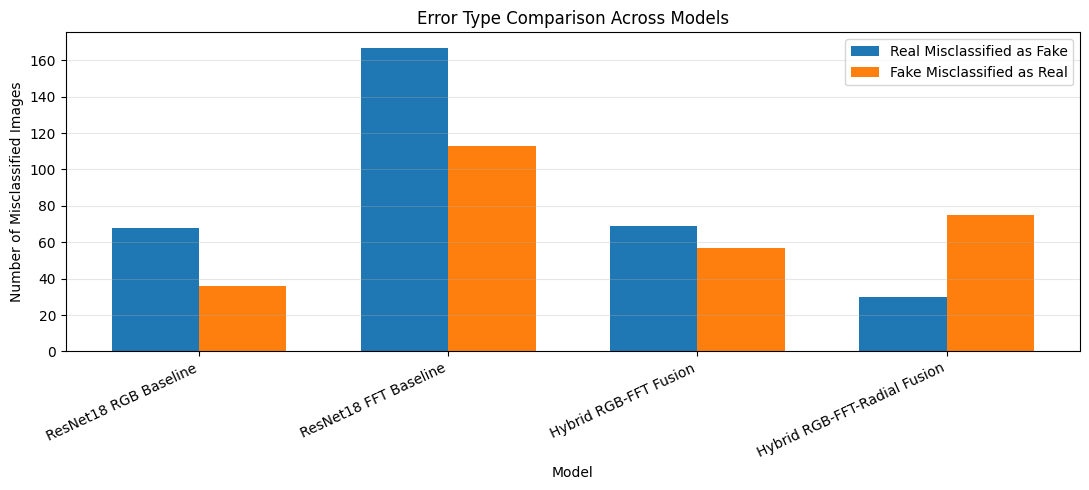

In [12]:
# ============================================================
# 11. Error Type Comparison
# ============================================================

error_df = pd.DataFrame({
    "Model": confusion_df["Model"],
    "False Fake": confusion_df["Actual Real → Predicted Fake"],
    "False Real": confusion_df["Actual Fake → Predicted Real"]
})

x = np.arange(len(error_df["Model"]))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, error_df["False Fake"], width, label="Real Misclassified as Fake")
plt.bar(x + width/2, error_df["False Real"], width, label="Fake Misclassified as Real")

plt.title("Error Type Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Number of Misclassified Images")
plt.xticks(x, error_df["Model"], rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 5. Ablation Study

The model comparison forms an ablation study.

## Ablation Components

| Experiment | RGB | FFT Magnitude | Radial Energy |
|---|---:|---:|---:|
| ResNet18 RGB Baseline | Yes | No | No |
| ResNet18 FFT Baseline | No | Yes | No |
| Hybrid RGB-FFT Fusion | Yes | Yes | No |
| Hybrid RGB-FFT-Radial Fusion | Yes | Yes | Yes |

## Key Finding

The RGB-only model achieved the best overall F1-score.  
The RGB-FFT-Radial model achieved almost the same test accuracy and the highest precision.

This suggests that spatial RGB features are the strongest standalone representation in this dataset, while structured frequency features such as radial energy can provide useful complementary information.

In [14]:
# ============================================================
# 12. Ablation Component Table
# ============================================================

ablation_data = {
    "Model": [
        "ResNet18 RGB Baseline",
        "ResNet18 FFT Baseline",
        "Hybrid RGB-FFT Fusion",
        "Hybrid RGB-FFT-Radial Fusion"
    ],
    "RGB Spatial Features": [
        "Yes", "No", "Yes", "Yes"
    ],
    "FFT Magnitude Features": [
        "No", "Yes", "Yes", "Yes"
    ],
    "Radial Energy Features": [
        "No", "No", "No", "Yes"
    ],
    "Test Accuracy (%)": [
        87.00,
        65.00,
        84.25,
        86.88
    ],
    "F1-score (%)": [
        87.50,
        67.21,
        84.48,
        86.09
    ]
}

ablation_df = pd.DataFrame(ablation_data)
ablation_df

,Model,RGB Spatial Features,FFT Magnitude Features,Radial Energy Features,Test Accuracy (%),F1-score (%)
0,ResNet18 RGB Baseline,Yes,No,No,87.00,87.50
1,ResNet18 FFT Baseline,No,Yes,No,65.00,67.21
2,Hybrid RGB-FFT Fusion,Yes,Yes,No,84.25,84.48
3,Hybrid RGB-FFT-Radial Fusion,Yes,Yes,Yes,86.88,86.09


# 6. Main Findings

## Finding 1: RGB spatial features are the strongest standalone representation

The RGB ResNet18 baseline achieved the highest test accuracy and F1-score.

This indicates that visual texture, color, composition, and spatial cues are highly informative for detecting AI-generated images in this dataset.

## Finding 2: FFT-only classification overfits strongly

The FFT-only ResNet18 model achieved high training accuracy but low validation and test accuracy.

This suggests that raw FFT magnitude spectra alone are not sufficient for robust detection in this simplified setup.

## Finding 3: Simple RGB-FFT fusion does not guarantee improvement

The RGB-FFT fusion model performed much better than FFT-only classification but did not outperform RGB-only classification.

This suggests that frequency information must be carefully integrated rather than simply concatenated.

## Finding 4: Radial energy improves precision

The RGB-FFT-Radial model achieved the highest precision.

This means it produced fewer false fake predictions and was more conservative when predicting the fake class.

## Finding 5: Frequency features are complementary, not a replacement

Overall, the experiments show that frequency-domain information is valuable, but it works best as a complementary signal alongside RGB spatial features.

# 7. Final Model Selection

Based on the evaluation results:

## Best overall model

**ResNet18 RGB Baseline**

Reason:

- Highest test accuracy
- Highest F1-score
- Highest fake recall
- Lowest complexity among strong-performing models

## Best high-precision model

**Hybrid RGB-FFT-Radial Fusion**

Reason:

- Highest precision
- Very close test accuracy to RGB baseline
- Incorporates paper-inspired spatial-frequency-radial fusion

## Final Project Interpretation

The RGB baseline is the strongest practical model in this experiment.

However, the RGB-FFT-Radial model provides the most research-oriented contribution because it incorporates structured frequency information inspired by recent spatial-frequency fusion studies.

In [18]:
# ============================================================
# 13. Save Final Comparison Tables
# ============================================================

results_df.to_csv("/kaggle/working/final_model_comparison_results.csv", index=False)
percentage_df.to_csv("/kaggle/working/final_model_comparison_percentage.csv", index=False)
confusion_df.to_csv("/kaggle/working/final_confusion_matrix_summary.csv", index=False)
ablation_df.to_csv("/kaggle/working/final_ablation_study.csv", index=False)

print("Final comparison tables saved successfully.")

Final comparison tables saved successfully.


# 8. Report-Ready Conclusion

This project investigated AI-generated image detection using spatial-domain, frequency-domain, and hybrid spatial-frequency approaches.

Four models were evaluated on the same balanced dataset split:

1. RGB ResNet18 baseline
2. FFT ResNet18 baseline
3. Hybrid RGB-FFT fusion model
4. Hybrid RGB-FFT-Radial energy fusion model

The RGB baseline achieved the best overall test accuracy and F1-score. The FFT-only model overfit heavily, showing that raw FFT magnitude spectra alone are not reliable enough in this setup. The RGB-FFT fusion model recovered strong performance but did not outperform RGB alone. The RGB-FFT-Radial model achieved the highest precision and nearly matched the RGB baseline accuracy, showing that structured frequency descriptors can provide complementary evidence.

The final conclusion is that spatial RGB features remain the strongest standalone representation for this dataset, while frequency-domain features are most useful when carefully structured and fused with spatial information.